In [1]:
from pathlib import Path
from itertools import product

import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

In [3]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")
df = pd.read_parquet(DATA_PATH)
df = df.rename(columns={"Total Load [MW]": "load"})
df = df.rename(columns={"Forecast Total Load [MW]": "terna-forecast"})

display(df.head())

,load,terna-forecast
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


In [4]:
df["lag_24h"] = df["load"].shift(24)
df["lag_48h"] = df["load"].shift(48)
df["lag_168h"] = df["load"].shift(168)

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h"]
    ].head(170)
)

,load,lag_24h,lag_48h,lag_168h
Date,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN
...,...,...,...,...
2023-01-07 21:00:00+01:00,1009.19525,1012.38225,1034.62100,NaN
2023-01-07 22:00:00+01:00,938.51400,943.02550,977.22425,NaN
2023-01-07 23:00:00+01:00,865.93575,863.03125,890.10025,NaN


In [5]:
italian_holidays = holidays.Italy(
    years=range(df.index.year.min(), df.index.year.max() + 1)
)

local_dates = df.index.tz_convert("Europe/Rome").date

In [6]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_holiday"] = [
    int(date in italian_holidays)
    for date in local_dates
]

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h",
         "hour", "day_of_week", "month", "is_holiday"]
    ].head()
)

,load,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_holiday
Date,,,,,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN,0,6,1,1
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN,1,6,1,1
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN,2,6,1,1
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN,3,6,1,1
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN,4,6,1,1


In [7]:
WEATHER_PATH = Path("../data/processed/sardinia_weather_hourly.parquet")
weather = pd.read_parquet(WEATHER_PATH)

weather.head()

,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max
time,,,,,
2024-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2024-01-01 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN


In [8]:
print("Load timezone:", df.index.tz)
print("Weather timezone:", weather.index.tz)

print("Load range:", df.index.min(), "->", df.index.max())
print("Weather range:", weather.index.min(), "->", weather.index.max())

Load timezone: Europe/Rome
Weather timezone: UTC
Load range: 2023-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00
Weather range: 2024-01-01 00:00:00+00:00 -> 2026-10-05 23:00:00+00:00


In [9]:
df_weather = df.copy()

# Convert load timestamps to UTC
df_weather.index = df_weather.index.tz_convert("UTC")

# Join weather forecasts on the same physical timestamps
df_weather = df_weather.join(weather, how="left")

df_weather.tail()

,load,terna-forecast,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_holiday,temperature_weighted,humidity_weighted,cloud_cover_weighted,temperature_min,temperature_max
Date,,,,,,,,,,,,,,
2026-10-05 17:00:00+00:00,1040.31050,1047.87950,950.88050,961.34675,1035.88400,19,0,10,0,24.535286,66.480992,94.982923,20.7,26.7
2026-10-05 18:00:00+00:00,1023.90500,1035.48450,955.09125,944.11200,1028.13000,20,0,10,0,23.778437,69.203434,91.039723,19.1,25.4
2026-10-05 19:00:00+00:00,943.76200,952.27725,899.96900,866.38775,950.25450,21,0,10,0,23.056816,73.673647,100.000000,18.4,24.7
2026-10-05 20:00:00+00:00,876.53425,883.39825,825.99125,805.69525,876.46550,22,0,10,0,22.613356,77.427804,90.632193,18.2,24.1
2026-10-05 21:00:00+00:00,807.51325,812.17200,766.50825,756.42250,810.22375,23,0,10,0,22.111887,81.104100,98.283052,18.1,23.6


In [10]:
weather_features = [
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

print(df_weather[weather_features].isna().sum())

temperature_weighted    9205
humidity_weighted       9205
cloud_cover_weighted    9205
temperature_min         9205
temperature_max         9205
dtype: int64


In [11]:
features_weather = [
    "lag_24h",
    "lag_48h",
    "lag_168h",
    "hour",
    "day_of_week",
    "month",
    "is_holiday",
    "temperature_weighted",
    "humidity_weighted",
    "cloud_cover_weighted",
    "temperature_min",
    "temperature_max",
]

model_weather_df = df_weather[
    ["load"] + features_weather
].dropna()

print("Usable rows:", len(model_weather_df))
print("First timestamp:", model_weather_df.index.min())
print("Last timestamp:", model_weather_df.index.max())

Usable rows: 23626
First timestamp: 2024-01-19 12:00:00+00:00
Last timestamp: 2026-10-05 21:00:00+00:00


In [12]:
X_weather = model_weather_df[features_weather]
y_weather = model_weather_df["load"]

X_train = X_weather.loc[:"2025-12-31 22:59:59+00:00"]
y_train = y_weather.loc[X_train.index]

X_test = X_weather.loc["2025-12-31 23:00:00+00:00":]
y_test = y_weather.loc[X_test.index]

print("Train:", X_train.index.min(), "->", X_train.index.max())
print("Test:", X_test.index.min(), "->", X_test.index.max())

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train: 2024-01-19 12:00:00+00:00 -> 2025-12-31 22:00:00+00:00
Test: 2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00
Train rows: 17099
Test rows: 6527


In [13]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

In [14]:
rmse_xgb = root_mean_squared_error(y_test, pred_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
mape_xgb = mean_absolute_percentage_error(
    y_test,
    pred_xgb
) * 100

print(f"MAE XGBoost: {mae_xgb:.2f} MW")
print(f"RMSE XGBoost: {rmse_xgb:.2f} MW")
print(f"MAPE XGBoost: {mape_xgb:.2f}%")

MAE XGBoost: 32.65 MW
RMSE XGBoost: 49.49 MW
MAPE XGBoost: 2.99%


In [15]:
X = model_weather_df[features_weather]
y = model_weather_df["load"]

X_train_tune = X.loc[:"2025-09-30 21:59:59+00:00"]
y_train_tune = y.loc[X_train_tune.index]

X_val = X.loc[
    "2025-09-30 22:00:00+00:00":"2025-12-31 22:59:59+00:00"
]
y_val = y.loc[X_val.index]

print("Train:")
print(X_train_tune.index.min(), "->", X_train_tune.index.max())
print("Rows:", len(X_train_tune))

print("\nValidation:")
print(X_val.index.min(), "->", X_val.index.max())
print("Rows:", len(X_val))

Train:
2024-01-19 12:00:00+00:00 -> 2025-09-30 21:00:00+00:00
Rows: 14890

Validation:
2025-09-30 22:00:00+00:00 -> 2025-12-31 22:00:00+00:00
Rows: 2209


In [16]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
}

tuning_results = []

for max_depth, learning_rate, min_child_weight in product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["min_child_weight"],
):
    model = XGBRegressor(
        n_estimators=500,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=min_child_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train_tune, y_train_tune)
    pred_val = model.predict(X_val)

    tuning_results.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "min_child_weight": min_child_weight,
        "MAE": mean_absolute_error(y_val, pred_val),
        "RMSE": root_mean_squared_error(y_val, pred_val),
    })

tuning_results = (
    pd.DataFrame(tuning_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

tuning_results.head(10)

,max_depth,learning_rate,min_child_weight,MAE,RMSE
0,6,0.05,10,24.755054,33.853202
1,6,0.05,5,24.941675,34.151943
2,6,0.03,5,25.004456,34.409951
3,6,0.03,10,25.006767,34.263812
4,6,0.05,1,25.009139,34.094807
5,5,0.05,1,25.053433,34.261930
6,6,0.03,1,25.073996,34.309221
7,5,0.05,10,25.083971,34.213197
8,5,0.10,5,25.207101,34.448936
9,5,0.05,5,25.220557,34.399470


In [17]:
depth_results = []

for max_depth in [5, 6, 7, 8, 9]:
    model = XGBRegressor(
        n_estimators=500,
        max_depth=max_depth,
        learning_rate=0.05,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train_tune, y_train_tune)
    pred_val = model.predict(X_val)

    depth_results.append({
        "max_depth": max_depth,
        "MAE": mean_absolute_error(y_val, pred_val),
        "RMSE": root_mean_squared_error(y_val, pred_val),
    })

pd.DataFrame(depth_results)

,max_depth,MAE,RMSE
0,5,25.083971,34.213197
1,6,24.755054,33.853202
2,7,25.138814,34.305500
3,8,25.179081,34.274625
4,9,25.148722,34.195129


In [18]:
estimators_results = []

for n_estimators in [200, 300, 400, 500, 700, 1000]:
    model = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train_tune, y_train_tune)
    pred_val = model.predict(X_val)

    estimators_results.append({
        "n_estimators": n_estimators,
        "MAE": mean_absolute_error(y_val, pred_val),
        "RMSE": root_mean_squared_error(y_val, pred_val),
    })

pd.DataFrame(estimators_results)

,n_estimators,MAE,RMSE
0,200,25.209336,34.547540
1,300,24.872830,34.078360
2,400,24.789122,33.953817
3,500,24.755054,33.853202
4,700,24.885833,33.898909
5,1000,25.063393,34.072475


In [19]:
best_xgb_params = {
    "n_estimators": 500,
    "max_depth": 6,
    "learning_rate": 0.05,
    "min_child_weight": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

In [20]:
final_xgb = XGBRegressor(
    **best_xgb_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

final_xgb.fit(X_train, y_train)

pred_xgb_final = final_xgb.predict(X_test)

mae_xgb_final = mean_absolute_error(y_test, pred_xgb_final)
rmse_xgb_final = root_mean_squared_error(y_test, pred_xgb_final)
mape_xgb_final = mean_absolute_percentage_error(
    y_test, pred_xgb_final
) * 100

print(f"Final XGBoost MAE: {mae_xgb_final:.2f} MW")
print(f"Final XGBoost RMSE: {rmse_xgb_final:.2f} MW")
print(f"Final XGBoost MAPE: {mape_xgb_final:.2f}%")

Final XGBoost MAE: 31.60 MW
Final XGBoost RMSE: 46.50 MW
Final XGBoost MAPE: 2.92%


In [21]:
results_xgb = pd.DataFrame(
    {
        "actual": y_test,
        "prediction": pred_xgb_final,
    },
    index=y_test.index,
)

results_xgb["error"] = (
    results_xgb["actual"] - results_xgb["prediction"]
)

results_xgb["absolute_error"] = (
    results_xgb["error"].abs()
)

results_xgb["absolute_percentage_error"] = (
    results_xgb["absolute_error"]
    / results_xgb["actual"]
    * 100
)

local_index = results_xgb.index.tz_convert("Europe/Rome")

results_xgb["hour"] = local_index.hour
results_xgb["day_of_week"] = local_index.dayofweek
results_xgb["month"] = local_index.month

In [22]:
mape_by_hour = (
    results_xgb
    .groupby("hour")["absolute_percentage_error"]
    .mean()
)

mape_by_weekday = (
    results_xgb
    .groupby("day_of_week")["absolute_percentage_error"]
    .mean()
)

mape_by_month = (
    results_xgb
    .groupby("month")["absolute_percentage_error"]
    .mean()
)

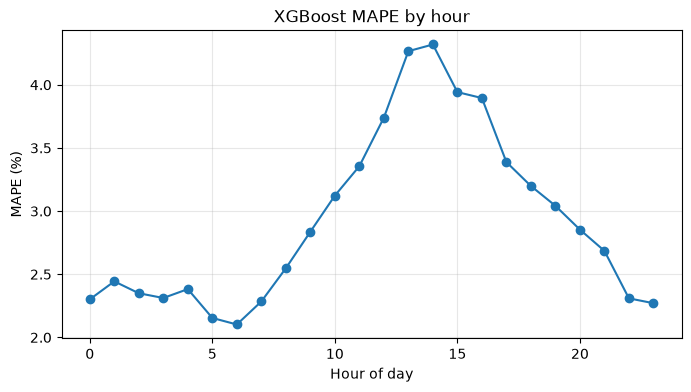

In [23]:
plt.figure(figsize=(8, 4))
mape_by_hour.plot(marker="o")
plt.xlabel("Hour of day")
plt.ylabel("MAPE (%)")
plt.title("XGBoost MAPE by hour")
plt.grid(alpha=0.3)
plt.show()

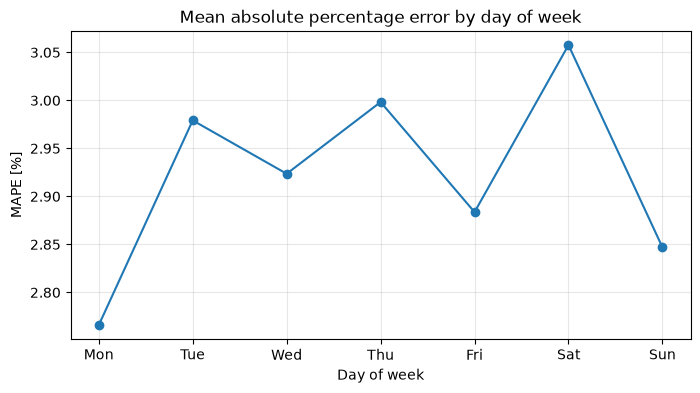

In [24]:
local_index = results_xgb.index.tz_convert("Europe/Rome")

mape_by_weekday = (
    results_xgb
    .groupby(local_index.dayofweek)["absolute_percentage_error"]
    .mean()
)

mape_by_weekday.index = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

fig, ax = plt.subplots(figsize=(8, 4))

mape_by_weekday.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

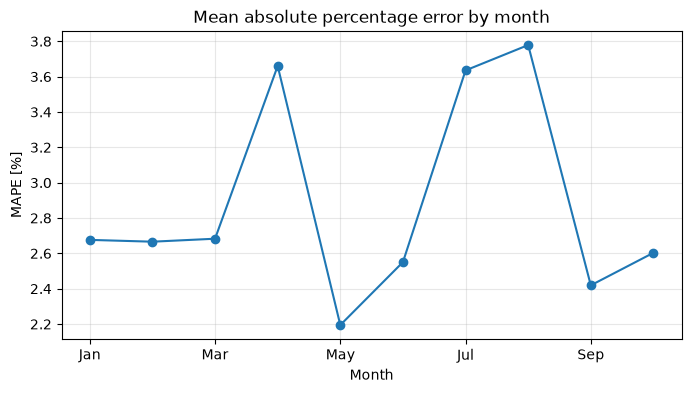

In [25]:
local_index = results_xgb.index.tz_convert("Europe/Rome")

mape_by_month = (
    results_xgb
    .groupby(local_index.month)["absolute_percentage_error"]
    .mean()
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

mape_by_month.index = [
    month_labels[month - 1]
    for month in mape_by_month.index
]

fig, ax = plt.subplots(figsize=(8, 4))

mape_by_month.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by month")
ax.set_xlabel("Month")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

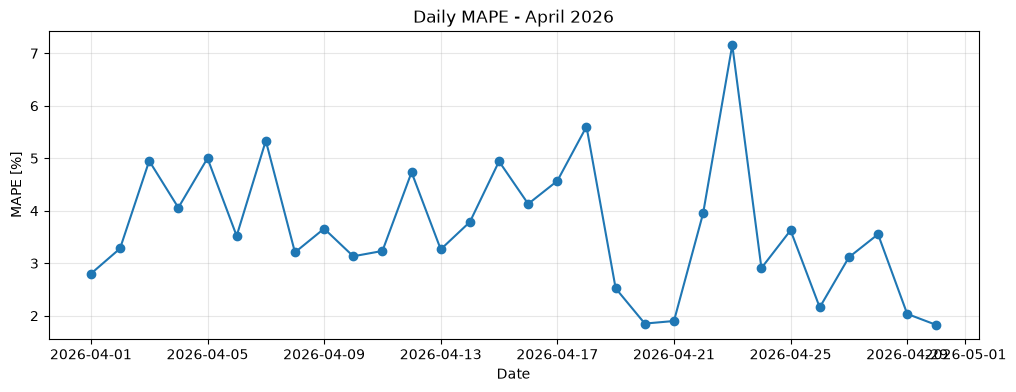

In [26]:
april = results_xgb[
    local_index.month == 4
].copy()

april["date"] = (
    april.index
    .tz_convert("Europe/Rome")
    .date
)

april_daily_mape = (
    april
    .groupby("date")["absolute_percentage_error"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 4))

april_daily_mape.plot(ax=ax, marker="o")

ax.set_title("Daily MAPE - April 2026")
ax.set_xlabel("Date")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

In [27]:
comparison = pd.DataFrame(index=X_test.index)

comparison["actual"] = y_test
comparison["xgboost"] = pred_xgb_final

comparison["baseline_24h"] = df_weather.loc[
    X_test.index, "lag_24h"
]

comparison["baseline_168h"] = df_weather.loc[
    X_test.index, "lag_168h"
]

comparison["terna"] = df_weather.loc[
    X_test.index, "terna-forecast"
]

print(comparison.isna().sum())
print("Rows before common filtering:", len(comparison))

comparison = comparison.dropna()

print("Common evaluation rows:", len(comparison))
print(comparison.index.min(), "->", comparison.index.max())

actual           0
xgboost          0
baseline_24h     0
baseline_168h    0
terna            0
dtype: int64
Rows before common filtering: 6527
Common evaluation rows: 6527
2025-12-31 23:00:00+00:00 -> 2026-10-05 21:00:00+00:00


In [28]:
metrics = []

for name in ["baseline_24h", "baseline_168h", "xgboost", "terna"]:
    metrics.append({
        "model": name,
        "MAE_MW": mean_absolute_error(
            comparison["actual"], comparison[name]
        ),
        "RMSE_MW": root_mean_squared_error(
            comparison["actual"], comparison[name]
        ),
        "MAPE_pct": mean_absolute_percentage_error(
            comparison["actual"], comparison[name]
        ) * 100,
    })

metrics_df = (
    pd.DataFrame(metrics)
    .set_index("model")
    .round(3)
)

metrics_df

,MAE_MW,RMSE_MW,MAPE_pct
model,,,
baseline_24h,44.764,63.707,4.309
baseline_168h,63.659,89.450,5.982
xgboost,31.598,46.505,2.921
terna,16.255,22.898,1.557


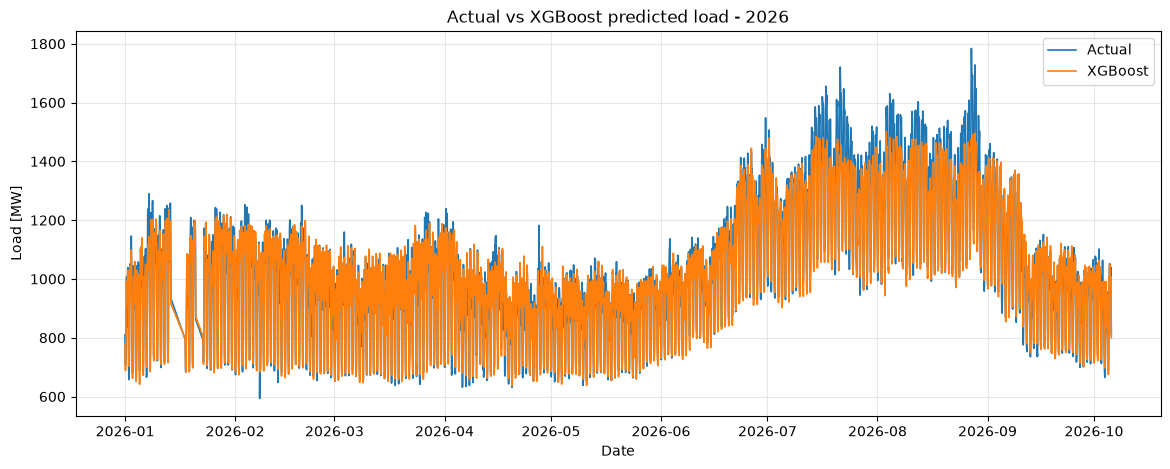

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    results_xgb.index,
    results_xgb["actual"],
    label="Actual",
    linewidth=1.2,
)

ax.plot(
    results_xgb.index,
    results_xgb["prediction"],
    label="XGBoost",
    linewidth=1.2,
)

ax.set_title("Actual vs XGBoost predicted load - 2026")
ax.set_xlabel("Date")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

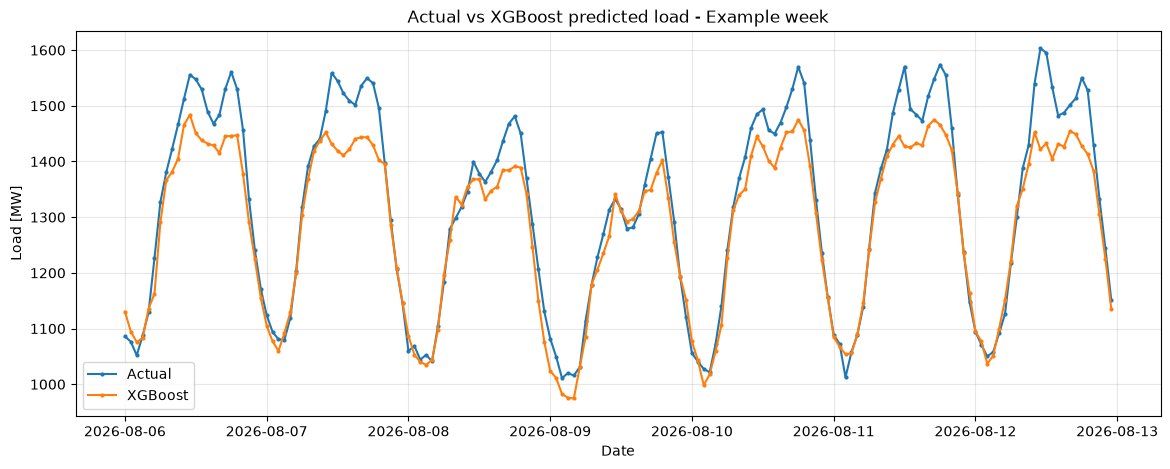

In [30]:
week = results_xgb.loc[
    "2026-08-06":"2026-08-12"
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    week.index,
    week["actual"],
    label="Actual",
    marker="o",
    markersize=2,
)

ax.plot(
    week.index,
    week["prediction"],
    label="XGBoost",
    marker="o",
    markersize=2,
)

ax.set_title("Actual vs XGBoost predicted load - Example week")
ax.set_xlabel("Date")
ax.set_ylabel("Load [MW]")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [31]:
results_xgb.to_parquet(
    "../data/processed/xgb_predictions.parquet"
)